In [40]:
%load_ext autoreload
%autoreload 2
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run experiment for toy data

In [5]:
import subprocess

# Define the parameters
experiment = "toy2d"
approach = "toy2d"
reg_type = "re_g"
q = [1.55] #have to set it manually in sweep-params, otherwise it reverts to the q in sweep-params
seed = 187

# Loop over the seeds and run the experiment
for alpha in q:
    print(f"Running experiment with q {alpha}")
    subprocess.run([
        "python", "./src/run.py",
        "--experiment", experiment,
        "--approach", approach,
        "--seed", str(seed),
        "--q", str(alpha),
        "--lr", "0.01",
        "--nepochs", "10",
        "--reg_type", reg_type
    ])

Running experiment with q 1.55


Traceback (most recent call last):
  File "/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/./src/run.py", line 31, in <module>
    data,taskcla,inputsize=dataloader.get(seed=args.seed, path=default_path)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/dataloaders/toy_data.py", line 233, in get
    generator = TaskDatasetGenerator(n_tasks=n_tasks, n_samples=n_samples)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/dataloaders/toy_data.py", line 147, in __init__
    self.datasets = self._generate_datasets()
                    ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/dataloaders/toy_data.py", line 204, in _generate_datasets
    X1, y1 = self._generate_task_data(centers)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nelosegui/BIFOLD_work/CL_curved/gvcl_for

Arguments =
	sweep_name: None
	seed: 187
	experiment: toy2d
	approach: toy2d
	reg_type: re_g
	q: 1.55
	v: 1
	output: ./res/toy2d/toy2d/re_g/187.txt
	nepochs: [10]
	lr: 0.01
	parameter: 
	ntasks: -1
	context: None
	momentum: 0.9
	weight_decay: 0.0001
	beta: 1
	lamb: 1
	root_path: ./
	use_best_hyperparams: False
	use_sweep: False
	train_samples: 10
	lr_schedule: False
	scheduler_type: cosine_anneal
	sbatch: 64
	optimizer: sgd
Load data...


## Visualize the experiment results

In [41]:
import numpy as np

# Path to the .npy file
file_path = 'res/toy2d/toy2d/re_g/187_output_dict.npy'

# Load the .npy file
output_dict = np.load(file_path, allow_pickle=True).item()


## Plotting the two tasks (old version)

Uses interpolation


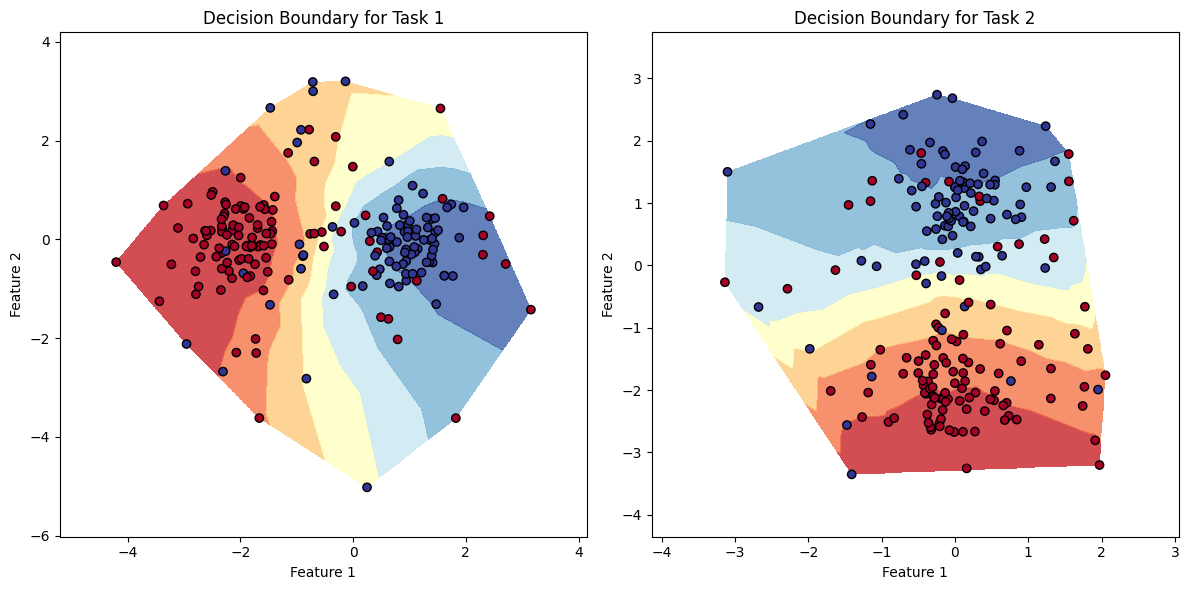

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Extract test data and prediction probabilities for task 1
xtest1 = output_dict["task_0"]["xtest"]
ytest1 = output_dict["task_0"]["ytest"]
output1 = output_dict["task_0"]["output"]

# Extract test data and prediction probabilities for task 2
xtest2 = output_dict["task_1"]["xtest"]
ytest2 = output_dict["task_1"]["ytest"]
output2 = output_dict["task_1"]["output"]

# Create a dense grid of points for task 1
x_min1, x_max1 = xtest1[:, 0].min() - 1, xtest1[:, 0].max() + 1
y_min1, y_max1 = xtest1[:, 1].min() - 1, xtest1[:, 1].max() + 1
xx1, yy1 = np.meshgrid(np.arange(x_min1, x_max1, 0.01),
                       np.arange(y_min1, y_max1, 0.01))

# Create a dense grid of points for task 2
x_min2, x_max2 = xtest2[:, 0].min() - 1, xtest2[:, 0].max() + 1
y_min2, y_max2 = xtest2[:, 1].min() - 1, xtest2[:, 1].max() + 1
xx2, yy2 = np.meshgrid(np.arange(x_min2, x_max2, 0.01),
                       np.arange(y_min2, y_max2, 0.01))

# Interpolate the probabilities for class 1 for task 1
Z1 = griddata(xtest1, output1[:, 1], (xx1, yy1), method='linear')

# Interpolate the probabilities for class 1 for task 2
Z2 = griddata(xtest2, output2[:, 1], (xx2, yy2), method='linear')

# Plot the decision boundaries side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot for task 1
ax1.contourf(xx1, yy1, Z1, alpha=0.8, cmap=plt.cm.RdYlBu)
ax1.scatter(xtest1[:, 0], xtest1[:, 1], c=ytest1, edgecolor='k', marker='o', cmap=plt.cm.RdYlBu)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Decision Boundary for Task 1')

# Plot for task 2
ax2.contourf(xx2, yy2, Z2, alpha=0.8, cmap=plt.cm.RdYlBu)
ax2.scatter(xtest2[:, 0], xtest2[:, 1], c=ytest2, edgecolor='k', marker='o', cmap=plt.cm.RdYlBu)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_title('Decision Boundary for Task 2')

plt.tight_layout()
plt.show()

## New version: creates a meshgrid on the test points
Evaluates on trained model

/tmp/ipykernel_1037939/1486977313.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


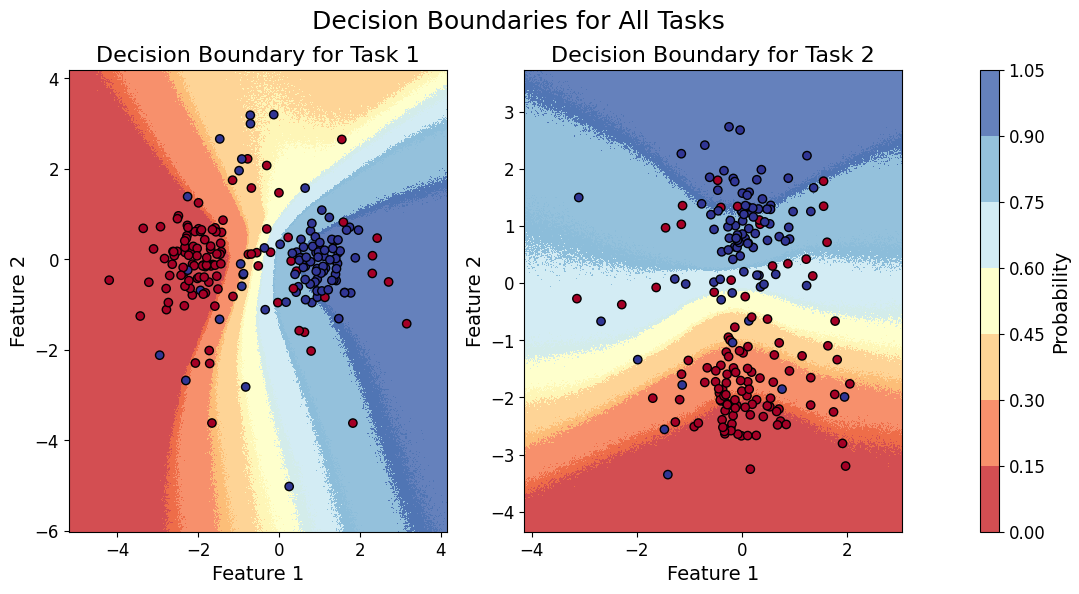

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def extract_task_data(output_dict, task_id):
    """Extract training and test data for a given task."""
    xtrain = output_dict[f"task_{task_id}"]["xtrain"]
    ytrain = output_dict[f"task_{task_id}"]["ytrain"]
    xtest = output_dict[f"task_{task_id}"]["xtest"]
    ytest = output_dict[f"task_{task_id}"]["ytest"]
    xx = output_dict[f"task_{task_id}"]['xx']
    yy = output_dict[f"task_{task_id}"]['yy']
    grid = output_dict[f"task_{task_id}"]['out_grid']
    return xtrain, ytrain, xtest, ytest, xx, yy, grid

def plot_decision_boundary(ax, xx, yy, grid, xtest, ytest, title):
    """Plot the decision boundary for a given task."""
    contour = ax.contourf(xx, yy, grid, alpha=0.8, cmap=plt.cm.RdYlBu)
    scatter = ax.scatter(xtest[:, 0], xtest[:, 1], c=ytest, edgecolor='k', marker='o', cmap=plt.cm.RdYlBu)
    ax.set_xlabel('Feature 1', fontsize=14)
    ax.set_ylabel('Feature 2', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    return contour

def plot_all_tasks(output_dict, n_tasks):
    """Plot decision boundaries for all tasks."""
    fig = plt.figure(figsize=(6 * n_tasks, 6))
    gs = GridSpec(1, n_tasks + 1, width_ratios=[1] * n_tasks + [0.05], wspace=0.3)

    contours = []
    axes = []
    for i in range(n_tasks):
        ax = fig.add_subplot(gs[i])
        axes.append(ax)
        xtrain, ytrain, xtest, ytest, xx, yy, grid = extract_task_data(output_dict, i)
        contour = plot_decision_boundary(ax, xx, yy, grid, xtest, ytest, f'Decision Boundary for Task {i+1}')
        contours.append(contour)

    # Add a single colorbar to the right of the plots
    cbar_ax = fig.add_subplot(gs[-1])
    cbar = fig.colorbar(contours[0], cax=cbar_ax)
    cbar.set_label('Probability', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    plt.suptitle('Decision Boundaries for All Tasks', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Example usage
n_tasks = 2  # Adjust this based on the number of tasks
plot_all_tasks(output_dict, n_tasks)

/tmp/ipykernel_1058347/3428534984.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


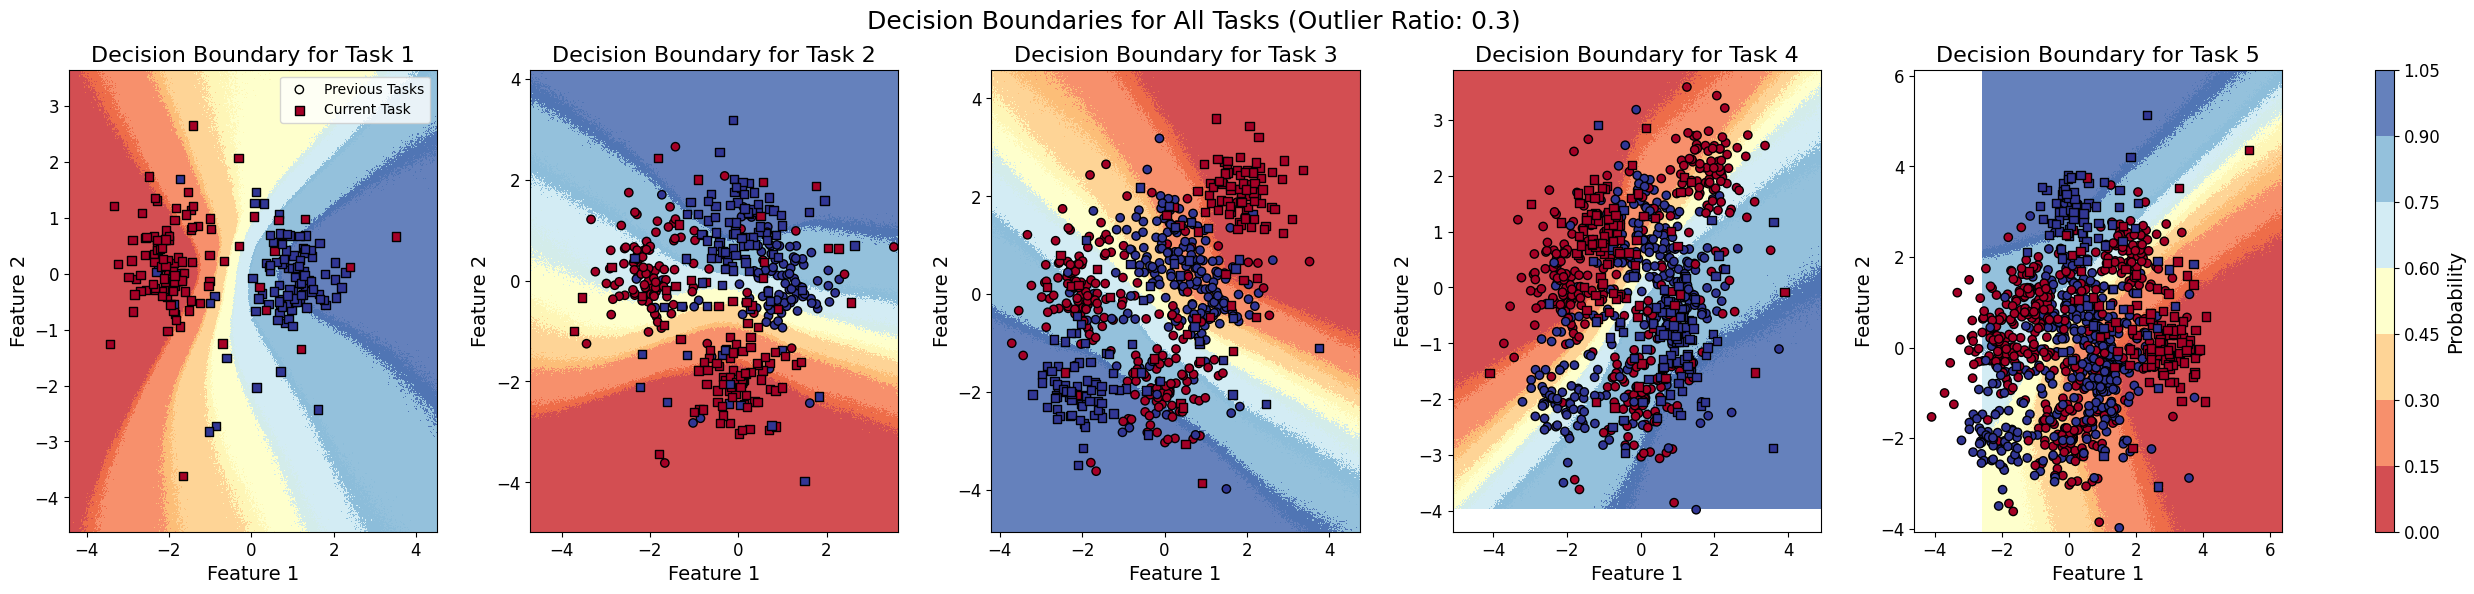

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

outlier_ratio = 0.3

def extract_task_data(output_dict, task_id):
    """Extract training and test data for a given task."""
    xtrain = output_dict[f"task_{task_id}"]["xtrain"]
    ytrain = output_dict[f"task_{task_id}"]["ytrain"]
    xtest = output_dict[f"task_{task_id}"]["xtest"]
    ytest = output_dict[f"task_{task_id}"]["ytest"]
    xx = output_dict[f"task_{task_id}"]['xx']
    yy = output_dict[f"task_{task_id}"]['yy']
    grid = output_dict[f"task_{task_id}"]['out_grid']
    return xtrain, ytrain, xtest, ytest, xx, yy, grid

def plot_decision_boundary(ax, xx, yy, grid, xtest, ytest, xtest_current, ytest_current, title, add_legend=False):
    """Plot the decision boundary for a given task."""
    contour = ax.contourf(xx, yy, grid, alpha=0.8, cmap=plt.cm.RdYlBu)
    ax.scatter(xtest[:, 0], xtest[:, 1], c=ytest, edgecolor='k', marker='o', cmap=plt.cm.RdYlBu, label='Previous Tasks' if add_legend else "")
    ax.scatter(xtest_current[:, 0], xtest_current[:, 1], c=ytest_current, edgecolor='k', marker='s', cmap=plt.cm.RdYlBu, label='Current Task' if add_legend else "")
    ax.set_xlabel('Feature 1', fontsize=14)
    ax.set_ylabel('Feature 2', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    if add_legend:
        ax.legend()
    return contour

def plot_all_tasks(output_dict, n_tasks, save_path, outlier_ratio):
    """Plot decision boundaries for all tasks."""
    fig = plt.figure(figsize=(6 * n_tasks, 6))
    gs = GridSpec(1, n_tasks + 1, width_ratios=[1] * n_tasks + [0.05], wspace=0.3)

    contours = []
    axes = []
    all_xtest = []
    all_ytest = []
    
    for i in range(n_tasks):
        ax = fig.add_subplot(gs[i])
        axes.append(ax)
        xtrain, ytrain, xtest, ytest, xx, yy, grid = extract_task_data(output_dict, i)
        
        # Accumulate test points
        all_xtest.append(xtest)
        all_ytest.append(ytest)
        
        # Combine all test points up to the current task
        combined_xtest = np.vstack(all_xtest[:-1]) if i > 0 else np.empty((0, xtest.shape[1]))
        combined_ytest = np.hstack(all_ytest[:-1]) if i > 0 else np.empty((0,))
        
        add_legend = (i == 0)  # Add legend only for the first plot
        contour = plot_decision_boundary(ax, xx, yy, grid, combined_xtest, combined_ytest, xtest, ytest, f'Decision Boundary for Task {i+1}', add_legend)
        contours.append(contour)

    # Add a single colorbar to the right of the plots
    cbar_ax = fig.add_subplot(gs[-1])
    cbar = fig.colorbar(contours[0], cax=cbar_ax)
    cbar.set_label('Probability', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    plt.suptitle(f'Decision Boundaries for All Tasks (Outlier Ratio: {outlier_ratio})', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.savefig(save_path)
    plt.show()

# Example usage
n_tasks = 5  # Adjust this based on the number of tasks
file_name = os.path.splitext(os.path.basename(file_path))[0]
save_path = os.path.join(os.path.dirname(file_path), f"{file_name}.png")
plot_all_tasks(output_dict, n_tasks, save_path, outlier_ratio)